In [3]:
import os
import random
import datetime
import numpy as np
import tensorflow as tf
import keras
from keras import layers, Model
from keras.applications import MobileNetV2
import matplotlib.pyplot as plt

In [4]:
DATA_DIR = '/Users/addosakah/Desktop/COE3/Sem 2/Software engineering/AgriConnect project/AgriConnect AI/AgriConnect_Final_dataset'

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

CROP_NAMES  = ['carrot', 'cucumber', 'mango', 'okra',
               'orange', 'pepper', 'plantain', 'potato', 'tomato']
FRESH_NAMES = ['aging', 'fresh', 'spoiled']   # alphabetical — matches folder sort

NUM_CROPS = len(CROP_NAMES)   # 9
NUM_FRESH = len(FRESH_NAMES)  # 3

# Maps stage folder name → integer index (alphabetical = what keras flow_from_directory uses)
FRESH_LABEL = {'aging': 0, 'fresh': 1, 'spoiled': 2}

THREE_STAGE_CROPS = ['carrot', 'mango', 'pepper', 'plantain', 'potato', 'tomato']
TWO_STAGE_CROPS   = ['cucumber', 'okra', 'orange']

# Shelf-life days per crop per stage — used for regression head labels
# CY updates these values during Phase 4 calibration
SHELF_LIFE_DAYS = {
    'tomato':   {'fresh': 7,  'aging': 3,  'spoiled': 0},
    'plantain': {'fresh': 6,  'aging': 3,  'spoiled': 0},
    'pepper':   {'fresh': 8,  'aging': 3,  'spoiled': 0},
    'carrot':   {'fresh': 14, 'aging': 5,  'spoiled': 0},
    'mango':    {'fresh': 6,  'aging': 2,  'spoiled': 0},
    'potato':   {'fresh': 21, 'aging': 7,  'spoiled': 0},
    'cucumber': {'fresh': 7,  'aging': 3,  'spoiled': 0},
    'okra':     {'fresh': 4,  'aging': 2,  'spoiled': 0},
    'orange':   {'fresh': 14, 'aging': 5,  'spoiled': 0},
}

MIN_IMAGES_PER_CLASS = 300

print("✅ CELL 1 done — imports and constants loaded")
print(f"   DATA_DIR: {DATA_DIR}")
print(f"   Crops: {CROP_NAMES}")
print(f"   Freshness classes: {FRESH_NAMES}")

✅ CELL 1 done — imports and constants loaded
   DATA_DIR: /Users/addosakah/Desktop/COE3/Sem 2/Software engineering/AgriConnect project/AgriConnect AI/AgriConnect_Final_dataset
   Crops: ['carrot', 'cucumber', 'mango', 'okra', 'orange', 'pepper', 'plantain', 'potato', 'tomato']
   Freshness classes: ['aging', 'fresh', 'spoiled']


In [5]:
def build_agriconnect_model(
    img_size=IMG_SIZE,
    num_crops=NUM_CROPS,
    num_fresh=NUM_FRESH,
    dropout_rate=0.3,
):
    """
    MobileNetV2 backbone with two classification heads:
      crop_output  → 9-class softmax (which crop is being scanned)
      fresh_output → 3-class softmax (aging=0 / fresh=1 / spoiled=2)

    Phase 1: backbone frozen — only heads train
    Phase 2: top 30 backbone layers unfrozen — fine-tune at low LR
    """
    inputs = layers.Input(shape=(*img_size, 3), name="image_input")

    base_model = MobileNetV2(
        input_shape=(*img_size, 3),
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False   # frozen for Phase 1

    # Normalise pixels 0–255 → -1 to 1 (MobileNetV2 requirement)
    x = keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="bn_shared")(x)
    x = layers.Dropout(dropout_rate, name="drop_shared")(x)

    # Shared trunk
    x = layers.Dense(256, activation="relu", name="dense_shared")(x)
    x = layers.BatchNormalization(name="bn_trunk")(x)
    x = layers.Dropout(dropout_rate, name="drop_trunk")(x)

    # Head 1 — crop classification
    crop_branch = layers.Dense(128, activation="relu", name="dense_crop")(x)
    crop_branch = layers.Dropout(dropout_rate * 0.5, name="drop_crop")(crop_branch)
    crop_output = layers.Dense(
        num_crops, activation="softmax", name="crop_output"
    )(crop_branch)

    # Head 2 — freshness classification
    fresh_branch = layers.Dense(128, activation="relu", name="dense_fresh")(x)
    fresh_branch = layers.Dropout(dropout_rate * 0.5, name="drop_fresh")(fresh_branch)
    fresh_output = layers.Dense(
        num_fresh, activation="softmax", name="fresh_output"
    )(fresh_branch)

    model = Model(
        inputs=inputs,
        outputs={"crop_output": crop_output, "fresh_output": fresh_output},
        name="AgriConnect_MobileNetV2",
    )
    return model, base_model


def compile_model(model, learning_rate=1e-3,
                  crop_loss_weight=0.4, fresh_loss_weight=0.6):
    """
    Freshness weighted higher (0.6) — it is the primary business signal.
    Crop weighted lower (0.4) — secondary, helps the model specialise.
    """
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss={
            "crop_output":  "categorical_crossentropy",
            "fresh_output": "categorical_crossentropy",
        },
        loss_weights={
            "crop_output":  crop_loss_weight,
            "fresh_output": fresh_loss_weight,
        },
        metrics={
            "crop_output":  [
                keras.metrics.CategoricalAccuracy(name="crop_acc"),
                keras.metrics.TopKCategoricalAccuracy(k=3, name="crop_top3"),
            ],
            "fresh_output": [
                keras.metrics.CategoricalAccuracy(name="fresh_acc"),
            ],
        },
    )
    return model


def unfreeze_top_layers(model, base_model,
                        num_layers_to_unfreeze=30, new_lr=1e-5):
    """Call after Phase 1 converges. Recompiles at much lower LR."""
    base_model.trainable = True
    for layer in base_model.layers[:-num_layers_to_unfreeze]:
        layer.trainable = False
    model = compile_model(model, learning_rate=new_lr)
    trainable = sum(1 for l in base_model.layers if l.trainable)
    print(f"Fine-tuning: {trainable}/{len(base_model.layers)} "
          f"MobileNetV2 layers unfrozen  (lr={new_lr})")
    return model


# Quick sanity check
model, base_model = build_agriconnect_model()
model = compile_model(model)
dummy = tf.zeros((2, 224, 224, 3))
out   = model(dummy, training=False)
print("\n✅ CELL 2 done — model built successfully")
for k, v in out.items():
    print(f"   {k}: {v.shape}")


✅ CELL 2 done — model built successfully
   crop_output: (2, 9)
   fresh_output: (2, 3)


In [6]:
def get_stages_for_crop(crop_name):
    if crop_name in TWO_STAGE_CROPS:
        return ['aging', 'spoiled']   # alphabetical — no fresh for these
    return ['aging', 'fresh', 'spoiled']


def load_image(path, crop_label, fresh_label):
    image_bytes = tf.io.read_file(path)
    image = tf.image.decode_image(
        image_bytes, channels=3, expand_animations=False
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize_with_pad(image, IMG_SIZE[0], IMG_SIZE[1])
    image = tf.cast(image, tf.float32)
    # Labels as one-hot for categorical_crossentropy
    crop_onehot  = tf.one_hot(crop_label,  NUM_CROPS)
    fresh_onehot = tf.one_hot(fresh_label, NUM_FRESH)
    return image, {"crop_output": crop_onehot, "fresh_output": fresh_onehot}


def augment_image(image, labels):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.85, upper=1.15)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.clip_by_value(image, 0.0, 255.0)
    return image, labels


def build_dataset(data_dir, split='train', batch_size=BATCH_SIZE,
                  oversample=True, min_images=MIN_IMAGES_PER_CLASS):
    image_paths  = []
    crop_labels  = []
    fresh_labels = []

    split_dir = os.path.join(data_dir, split)
    if not os.path.exists(split_dir):
        raise FileNotFoundError(
            f"Split folder not found: {split_dir}\n"
            f"Make sure your AgriConnect_Final folder has train/ val/ test/"
        )

    for crop in CROP_NAMES:
        crop_idx    = CROP_NAMES.index(crop)
        valid_stages = get_stages_for_crop(crop)

        for stage in valid_stages:
            folder_name = f"{crop}_{stage}"
            stage_dir   = os.path.join(split_dir, folder_name)

            if not os.path.exists(stage_dir):
                print(f"  SKIP (missing): {split}/{folder_name}")
                continue

            fresh_idx = FRESH_NAMES.index(stage)

            files = [
                os.path.join(stage_dir, f)
                for f in os.listdir(stage_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ]
            n = len(files)

            # Oversample small classes in training split only
            if oversample and split == 'train' and 0 < n < min_images:
                repeats = int(np.ceil(min_images / n))
                files   = (files * repeats)[:min_images]
                print(f"  {split:5} | {folder_name:25} | {n} → {len(files)} (oversampled)")
            else:
                print(f"  {split:5} | {folder_name:25} | {n} images")

            image_paths.extend(files)
            crop_labels.extend([crop_idx]  * len(files))
            fresh_labels.extend([fresh_idx] * len(files))

    if not image_paths:
        raise ValueError(f"No images found in {split_dir}")

    print(f"\n  Total {split}: {len(image_paths)} images\n")

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, crop_labels, fresh_labels)
    )
    dataset = dataset.map(
        lambda p, c, f: load_image(p, c, f),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if split == 'train':
        dataset = dataset.map(augment_image,
                              num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.shuffle(buffer_size=2000, seed=42)

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

Scanned 63 folders — 36418 total images

Class weights (freshness head): {0: 0.8207849750355454, 1: 1.3048940755927037, 2: 0.98492242986946}


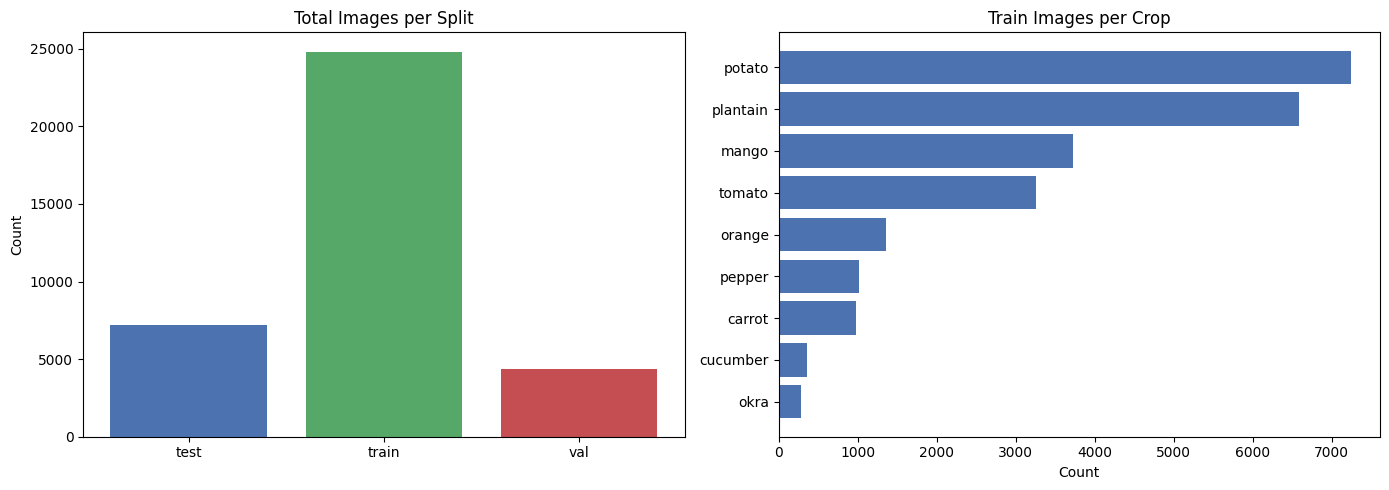

✅ CELL 4 done — dataset scanned and class weights computed


In [7]:
import pandas as pd

def scan_dataset_counts(data_dir, splits=('train', 'val', 'test')):
    records = []
    for split in splits:
        split_dir = os.path.join(data_dir, split)
        if not os.path.exists(split_dir):
            continue
        for crop in CROP_NAMES:
            for stage in get_stages_for_crop(crop):
                folder_name = f"{crop}_{stage}"
                stage_dir   = os.path.join(split_dir, folder_name)
                if not os.path.exists(stage_dir):
                    continue
                count = sum(
                    1 for f in os.listdir(stage_dir)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
                )
                records.append({
                    'split': split, 'crop': crop,
                    'stage': stage, 'folder': folder_name, 'count': count
                })
    return pd.DataFrame(records)


df = scan_dataset_counts(DATA_DIR)
print(f"Scanned {len(df)} folders — {df['count'].sum()} total images\n")

# Class weights for freshness head (compensates for aging being underrepresented)
stage_counts = df[df['split'] == 'train'].groupby('stage')['count'].sum()
stage_counts = stage_counts.reindex(['aging', 'fresh', 'spoiled'])
total        = stage_counts.sum()
n_classes    = 3

class_weights = {
    i: total / (n_classes * stage_counts[stage])
    for i, stage in enumerate(['aging', 'fresh', 'spoiled'])
}
print("Class weights (freshness head):", class_weights)

# Quick visualisation of dataset distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

split_totals = df.groupby('split')['count'].sum()
axes[0].bar(split_totals.index, split_totals.values,
            color=['#4C72B0', '#55A868', '#C44E52'])
axes[0].set_title('Total Images per Split')
axes[0].set_ylabel('Count')

train_crop = df[df['split'] == 'train'].groupby('crop')['count'].sum().sort_values()
axes[1].barh(train_crop.index, train_crop.values, color='#4C72B0')
axes[1].set_title('Train Images per Crop')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

print("✅ CELL 4 done — dataset scanned and class weights computed")

In [9]:
print("Building train dataset...")
train_ds = build_dataset(DATA_DIR, split='train', oversample=True)

print("Building val dataset...")
val_ds   = build_dataset(DATA_DIR, split='val',   oversample=False)

print("Building test dataset...")
test_ds  = build_dataset(DATA_DIR, split='test',  oversample=False)

# Confirm one batch loads correctly
for images, labels in train_ds.take(1):
    print(f"\nBatch image shape:    {images.shape}")
    print(f"crop_output shape:    {labels['crop_output'].shape}")
    print(f"fresh_output shape:   {labels['fresh_output'].shape}")

print("✅ CELL 5 done — train / val / test datasets ready")

Building train dataset...
  train | carrot_aging              | 166 → 300 (oversampled)
  train | carrot_fresh              | 712 images
  train | carrot_spoiled            | 104 → 300 (oversampled)
  SKIP (missing): train/cucumber_aging
  train | cucumber_spoiled          | 358 images
  train | mango_aging               | 1148 images
  train | mango_fresh               | 1242 images
  train | mango_spoiled             | 1337 images
  SKIP (missing): train/okra_aging
  train | okra_spoiled              | 288 → 300 (oversampled)
  SKIP (missing): train/orange_aging
  train | orange_spoiled            | 1356 images
  train | pepper_aging              | 529 images
  train | pepper_fresh              | 253 → 300 (oversampled)
  train | pepper_spoiled            | 231 → 300 (oversampled)
  train | plantain_aging            | 1997 images
  train | plantain_fresh            | 2098 images
  train | plantain_spoiled          | 2493 images
  train | potato_aging              | 6110 images
  trai

2026-07-27 01:05:55.616201: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-27 01:05:55.646928: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-27 01:05:55.651607: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile



Batch image shape:    (32, 224, 224, 3)
crop_output shape:    (32, 9)
fresh_output shape:   (32, 3)
✅ CELL 5 done — train / val / test datasets ready


2026-07-27 01:05:57.105056: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:
checkpoint_path = "best_model_phase01.keras"

callbacks_phase1 = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor='val_fresh_output_fresh_acc',
        save_best_only=True,
        mode='max',          # <-- add this line
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_fresh_output_fresh_acc',
        patience=7,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.TensorBoard(
        log_dir=f"logs/phase1_{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}"
    ),
]

# Rebuild fresh model
model, base_model = build_agriconnect_model()
model = compile_model(model, learning_rate=1e-3)

print("Starting Phase 1 training (frozen backbone)...")
print("Target: val fresh_acc > 0.80\n")

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_phase1,
)

print("✅ CELL 6 done — Phase 1 training complete")

Starting Phase 1 training (frozen backbone)...
Target: val fresh_acc > 0.80

Epoch 1/15


2026-07-27 01:07:55.765607: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-27 01:07:55.803335: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-27 01:07:55.812850: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


602/796 ━━━━━━━━━━━━━━━━━━━━ 4:06 1s/step - crop_output_crop_acc: 0.8985 - crop_output_crop_top3: 0.9595 - crop_output_loss: 0.3641 - fresh_output_fresh_acc: 0.8761 - fresh_output_loss: 0.3309 - loss: 0.3442

2026-07-27 01:20:42.607599: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


603/796 ━━━━━━━━━━━━━━━━━━━━ 4:05 1s/step - crop_output_crop_acc: 0.8986 - crop_output_crop_top3: 0.9595 - crop_output_loss: 0.3638 - fresh_output_fresh_acc: 0.8762 - fresh_output_loss: 0.3307 - loss: 0.3440

...

731/796 ━━━━━━━━━━━━━━━━━━━━ 1:15 1s/step - crop_output_crop_acc: 0.9673 - crop_output_crop_top3: 0.9968 - crop_output_loss: 0.1041 - fresh_output_fresh_acc: 0.9438 - fresh_output_loss: 0.1374 - loss: 0.1241

2026-07-27 05:20:48.129465: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


796/796 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - crop_output_crop_acc: 0.9683 - crop_output_crop_top3: 0.9970 - crop_output_loss: 0.1010 - fresh_output_fresh_acc: 0.9453 - fresh_output_loss: 0.1345 - loss: 0.1211

2026-07-27 05:21:58.730337: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-27 05:21:59.779862: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-27 05:24:10.082806: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-27 05:24:10.085826: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-27 05:24:11.214834: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-27 05:24:11.214961: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-27 05:24:11.215061: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-27 05:24:11.215355: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-27 05:24:11.215425: W tensorflow/core/lib/png/png_io.cc:89] PNG 


Epoch 15: val_fresh_output_fresh_acc improved from 0.93045 to 0.93114, saving model to best_model_phase01.keras
796/796 ━━━━━━━━━━━━━━━━━━━━ 1090s 1s/step - crop_output_crop_acc: 0.9803 - crop_output_crop_top3: 0.9986 - crop_output_loss: 0.0637 - fresh_output_fresh_acc: 0.9626 - fresh_output_loss: 0.0997 - loss: 0.0854 - val_crop_output_crop_acc: 0.8625 - val_crop_output_crop_top3: 0.9973 - val_crop_output_loss: 0.5109 - val_fresh_output_fresh_acc: 0.9311 - val_fresh_output_loss: 0.2368 - val_loss: 0.3474 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 15.
✅ CELL 6 done — Phase 1 training complete


NameError: name 'history_phase1' is not defined

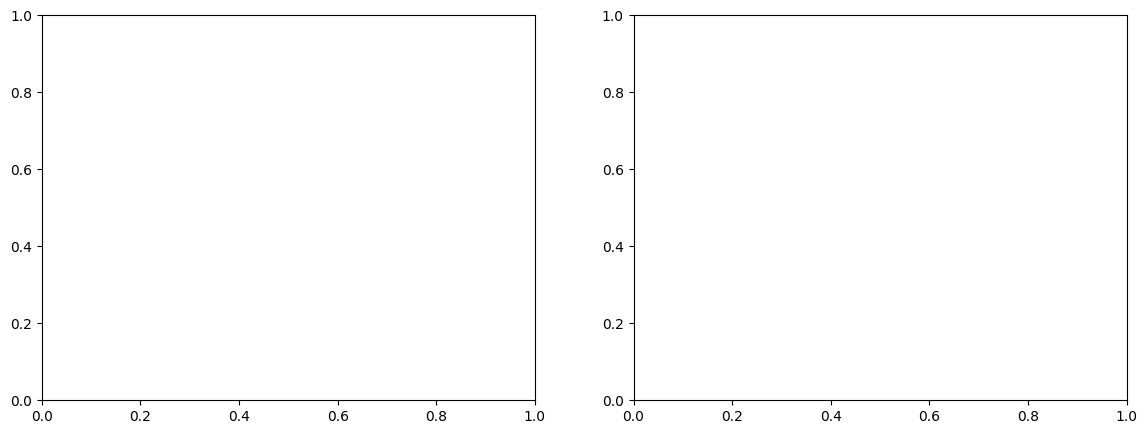

In [9]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_phase1.history['fresh_output_fresh_acc'],   label='train fresh_acc')
axes[0].plot(history_phase1.history['val_fresh_output_fresh_acc'], label='val fresh_acc')
axes[0].axhline(0.80, color='red', linestyle='--', label='Target 80%')
axes[0].set_title('Phase 1 — Freshness Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_phase1.history['loss'],     label='train loss')
axes[1].plot(history_phase1.history['val_loss'], label='val loss')
axes[1].set_title('Phase 1 — Total Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

# Evaluate on test set
print("Evaluating on test set...")
results_p1 = model.evaluate(test_ds, verbose=1)
print("\nPhase 1 test results:")
for name, val in zip(model.metrics_names, results_p1):
    print(f"  {name}: {val:.4f}")

print("✅ CELL 7 done — Phase 1 evaluation complete")


In [16]:
checkpoint_path_ft = "best_model_phase2.keras"

callbacks_phase2 = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path_ft,
        monitor='val_fresh_output_fresh_acc',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_fresh_output_fresh_acc',
        patience=5,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.TensorBoard(
        log_dir=f"logs/phase2_{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}"
    ),
]

# Unfreeze top 30 layers and recompile at very low LR
model = unfreeze_top_layers(model, base_model,
                            num_layers_to_unfreeze=30, new_lr=1e-5)

print("Starting Phase 2 fine-tuning (top 30 layers unfrozen)...")
print("Using LR=1e-5 to avoid destroying pretrained weights\n")

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=callbacks_phase2,
)

print("✅ CELL 8 done — Phase 2 fine-tuning complete")


Fine-tuning: 30/154 MobileNetV2 layers unfrozen  (lr=1e-05)
Starting Phase 2 fine-tuning (top 30 layers unfrozen)...
Using LR=1e-5 to avoid destroying pretrained weights

Epoch 1/3


2026-07-25 16:29:16.573329: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-25 16:29:16.595783: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-25 16:29:16.600339: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


266/796 ━━━━━━━━━━━━━━━━━━━━ 1:13:16 8s/step - crop_output_crop_acc: 0.1110 - crop_output_crop_top3: 0.3564 - crop_output_loss: 2.8134 - fresh_output_fresh_acc: 0.4149 - fresh_output_loss: 1.4023 - loss: 1.9667

KeyboardInterrupt: 

NameError: name 'history_phase2' is not defined

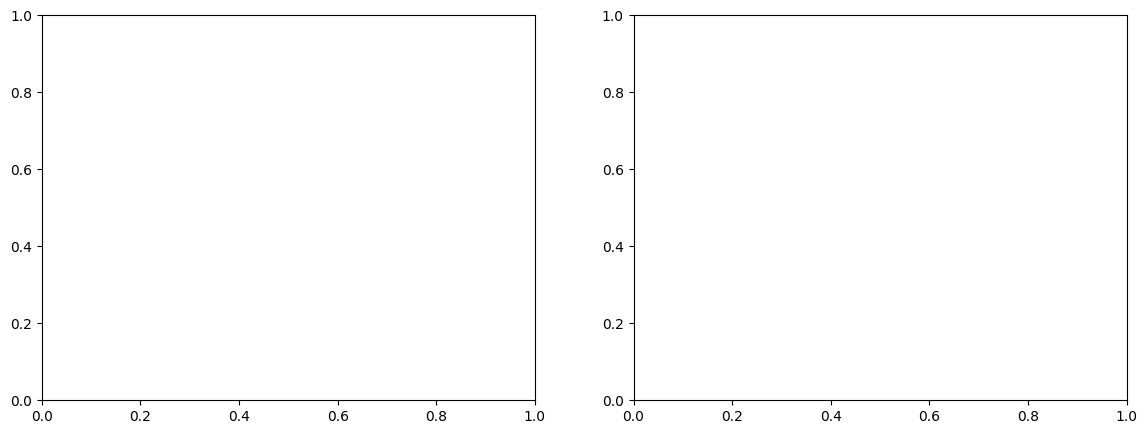

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_phase2.history['fresh_output_fresh_acc'],     label='train fresh_acc')
axes[0].plot(history_phase2.history['val_fresh_output_fresh_acc'], label='val fresh_acc')
axes[0].axhline(0.80, color='red', linestyle='--', label='Target 80%')
axes[0].set_title('Phase 2 Fine-tuning — Freshness Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_phase2.history['loss'],     label='train loss')
axes[1].plot(history_phase2.history['val_loss'], label='val loss')
axes[1].set_title('Phase 2 Fine-tuning — Total Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Evaluating Phase 2 on test set...")
results_p2 = model.evaluate(test_ds, verbose=1)
print("\nPhase 2 test results:")
for name, val in zip(model.metrics_names, results_p2):
    print(f"  {name}: {val:.4f}")

# Compare Phase 1 vs Phase 2 freshness accuracy
p1_acc = max(history_phase1.history.get('val_fresh_output_fresh_acc', [0]))
p2_acc = max(history_phase2.history.get('val_fresh_output_fresh_acc', [0]))
print(f"\nPhase 1 best val fresh_acc: {p1_acc:.4f}")
print(f"Phase 2 best val fresh_acc: {p2_acc:.4f}")
print(f"Improvement:                {(p2_acc - p1_acc)*100:.2f}%")
print("Target met (>80%): ", "✅ YES" if p2_acc >= 0.80 else "❌ NOT YET — check data quality")

print("✅ CELL 9 done — Phase 2 evaluation complete")

In [6]:
# Save the full Keras model
model.save("agriconnect_final.keras")
print("Full model saved → agriconnect_final.keras")

# Convert to TFLite (float16 quantisation — good balance of size vs accuracy)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_model = converter.convert()

tflite_path = "agriconnect_model.tflite"
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize(tflite_path) / (1024 * 1024)
print(f"TFLite model saved → {tflite_path}  ({size_mb:.2f} MB)")

# Quick inference test on the TFLite model
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Run one dummy image through
test_input = np.zeros((1, 224, 224, 3), dtype=np.float32)
interpreter.set_tensor(input_details[0]['index'], test_input)
interpreter.invoke()

print("\nTFLite output tensors:")
for od in output_details:
    result = interpreter.get_tensor(od['index'])
    print(f"  {od['name']}: shape={result.shape}, values={result}")

print("\n✅ CELL 10 done — TFLite model ready for Flutter integration")
print(f"   Hand agriconnect_model.tflite to Nana Akosua for Flutter embedding")
print(f"   Model size: {size_mb:.2f} MB")


NameError: name 'model' is not defined

In [2]:
print("\n" + "="*60)
print("AGRICONNECT MODEL TRAINING COMPLETE")
print("="*60)
print(f"Phase 1 best val freshness accuracy: {p1_acc*100:.1f}%")
print(f"Phase 2 best val freshness accuracy: {p2_acc*100:.1f}%")
print(f"Target (>80%): {'MET ✅' if p2_acc >= 0.80 else 'NOT MET ❌'}")
print(f"\nFiles produced:")
print(f"  agriconnect_final.keras     — full model")
print(f"  best_model_phase1.keras     — best phase 1 checkpoint")
print(f"  best_model_phase2.keras     — best phase 2 checkpoint")
print(f"  agriconnect_model.tflite    — deploy this in Flutter")
print("="*60)
ENDOFFILE



AGRICONNECT MODEL TRAINING COMPLETE


NameError: name 'p1_acc' is not defined

In [17]:
# ── RESUME FROM SAVED CHECKPOINT ─────────────────────────────
import os
import numpy as np
import tensorflow as tf
import keras
from keras import layers, Model
from keras.applications import MobileNetV2
import matplotlib.pyplot as plt

DATA_DIR = '/Users/addosakah/Desktop/COE3/Sem 2/Software engineering/AgriConnect project/AgriConnect AI/AgriConnect_Final_dataset'

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

CROP_NAMES  = ['carrot', 'cucumber', 'mango', 'okra',
               'orange', 'pepper', 'plantain', 'potato', 'tomato']
FRESH_NAMES = ['aging', 'fresh', 'spoiled']

NUM_CROPS = len(CROP_NAMES)
NUM_FRESH = len(FRESH_NAMES)

THREE_STAGE_CROPS = ['carrot', 'mango', 'pepper', 'plantain', 'potato', 'tomato']
TWO_STAGE_CROPS   = ['cucumber', 'okra', 'orange']

SHELF_LIFE_DAYS = {
    'tomato':   {'fresh': 7,  'aging': 3,  'spoiled': 0},
    'plantain': {'fresh': 6,  'aging': 3,  'spoiled': 0},
    'pepper':   {'fresh': 8,  'aging': 3,  'spoiled': 0},
    'carrot':   {'fresh': 14, 'aging': 5,  'spoiled': 0},
    'mango':    {'fresh': 6,  'aging': 2,  'spoiled': 0},
    'potato':   {'fresh': 21, 'aging': 7,  'spoiled': 0},
    'cucumber': {'fresh': 7,  'aging': 3,  'spoiled': 0},
    'okra':     {'fresh': 4,  'aging': 2,  'spoiled': 0},
    'orange':   {'fresh': 14, 'aging': 5,  'spoiled': 0},
}

MIN_IMAGES_PER_CLASS = 300


def get_stages_for_crop(crop_name):
    if crop_name in TWO_STAGE_CROPS:
        return ['aging', 'spoiled']
    return ['aging', 'fresh', 'spoiled']


def load_image(path, crop_label, fresh_label):
    image_bytes = tf.io.read_file(path)
    image = tf.image.decode_image(image_bytes, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize_with_pad(image, IMG_SIZE[0], IMG_SIZE[1])
    image = tf.cast(image, tf.float32)
    crop_onehot  = tf.one_hot(crop_label,  NUM_CROPS)
    fresh_onehot = tf.one_hot(fresh_label, NUM_FRESH)
    return image, {"crop_output": crop_onehot, "fresh_output": fresh_onehot}


def augment_image(image, labels):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.85, upper=1.15)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.clip_by_value(image, 0.0, 255.0)
    return image, labels


def build_dataset(data_dir, split='train', batch_size=BATCH_SIZE,
                  oversample=True, min_images=MIN_IMAGES_PER_CLASS):
    image_paths, crop_labels, fresh_labels = [], [], []
    split_dir = os.path.join(data_dir, split)
    if not os.path.exists(split_dir):
        raise FileNotFoundError(f"Split folder not found: {split_dir}")

    for crop in CROP_NAMES:
        crop_idx = CROP_NAMES.index(crop)
        for stage in get_stages_for_crop(crop):
            folder_name = f"{crop}_{stage}"
            stage_dir = os.path.join(split_dir, folder_name)
            if not os.path.exists(stage_dir):
                continue
            fresh_idx = FRESH_NAMES.index(stage)
            files = [os.path.join(stage_dir, f) for f in os.listdir(stage_dir)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            n = len(files)
            if oversample and split == 'train' and 0 < n < min_images:
                repeats = int(np.ceil(min_images / n))
                files = (files * repeats)[:min_images]
            image_paths.extend(files)
            crop_labels.extend([crop_idx] * len(files))
            fresh_labels.extend([fresh_idx] * len(files))

    if not image_paths:
        raise ValueError(f"No images found in {split_dir}")

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, crop_labels, fresh_labels))
    dataset = dataset.map(lambda p, c, f: load_image(p, c, f), num_parallel_calls=tf.data.AUTOTUNE)
    if split == 'train':
        dataset = dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.shuffle(buffer_size=2000, seed=42)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset


# ── Load your already-trained model ──────────────────────────
model = keras.models.load_model("best_model_phase1.keras")
print("✅ Loaded best_model_phase1.keras")
model.summary()

# ── Rebuild datasets (fast — just paths, no training) ────────
val_ds  = build_dataset(DATA_DIR, split='val',  oversample=False)
test_ds = build_dataset(DATA_DIR, split='test', oversample=False)

# ── Evaluate immediately, no training needed ──────────────────
results = model.evaluate(test_ds, return_dict=True, verbose=1)
print("\nLoaded-model test results:")
for k, v in results.items():
    print(f"  {k}: {v:.4f}")

✅ Loaded best_model_phase1.keras


Model: "AgriConnect_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_1       │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_1          │ (None, 224, 224,  │          0 │ true_divide_1[0]… │
│ (Subtract)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ subtract_1[0][0]  │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_shared           │ (None, 1280)      │      5,120 │ gap[0][0]         │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_shared         │ (None, 1280)      │          0 │ bn_shared[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_shared        │ (None, 256)       │    327,936 │ drop_shared[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_trunk            │ (None, 256)       │      1,024 │ dense_shared[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_trunk          │ (None, 256)       │          0 │ bn_trunk[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_crop (Dense)  │ (None, 128)       │     32,896 │ drop_trunk[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_fresh (Dense) │ (None, 128)       │     32,896 │ drop_trunk[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_crop (Dropout) │ (None, 128)       │          0 │ dense_crop[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_fresh          │ (None, 128)       │          0 │ dense_fresh[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ crop_output (Dense) │ (None, 9)         │      1,161 │ drop_crop[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fresh_output        │ (None, 3)         │        387 │ drop_fresh[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,456,102 (13.18 MB)

 Trainable params: 398,348 (1.52 MB)

...

217/226 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - crop_output_crop_acc: 0.2477 - crop_output_crop_top3: 0.9107 - crop_output_loss: 3.7544 - fresh_output_fresh_acc: 0.6282 - fresh_output_loss: 1.8082 - loss: 2.5867

2026-07-25 17:19:38.209122: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-25 17:19:38.209156: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-25 17:19:38.210165: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-25 17:19:38.210618: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-25 17:19:38.217999: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-25 17:19:38.220526: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-25 17:19:38.220783: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-25 17:19:38.221397: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-25 17:19:38.225856: W tensorflow/core/lib/png/png_io.cc:89] PNG 

218/226 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - crop_output_crop_acc: 0.2489 - crop_output_crop_top3: 0.9109 - crop_output_loss: 3.7482 - fresh_output_fresh_acc: 0.6290 - fresh_output_loss: 1.8042 - loss: 2.5818 

2026-07-25 17:19:39.298847: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


226/226 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - crop_output_crop_acc: 0.5105 - crop_output_crop_top3: 0.9574 - crop_output_loss: 2.3127 - fresh_output_fresh_acc: 0.7976 - fresh_output_loss: 0.8887 - loss: 1.4599

Loaded-model test results:
  crop_output_crop_acc: 0.5105
  crop_output_crop_top3: 0.9574
  crop_output_loss: 2.3127
  fresh_output_fresh_acc: 0.7976
  fresh_output_loss: 0.8887
  loss: 1.4599


In [12]:
import keras
model = keras.models.load_model("best_model_phase01.keras")  # or whatever name it has after upload
print("✅ Loaded")
model.summary()

✅ Loaded


Model: "AgriConnect_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_2       │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_2          │ (None, 224, 224,  │          0 │ true_divide_2[0]… │
│ (Subtract)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ subtract_2[0][0]  │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_shared           │ (None, 1280)      │      5,120 │ gap[0][0]         │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_shared         │ (None, 1280)      │          0 │ bn_shared[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_shared        │ (None, 256)       │    327,936 │ drop_shared[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_trunk            │ (None, 256)       │      1,024 │ dense_shared[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_trunk          │ (None, 256)       │          0 │ bn_trunk[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_crop (Dense)  │ (None, 128)       │     32,896 │ drop_trunk[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_fresh (Dense) │ (None, 128)       │     32,896 │ drop_trunk[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_crop (Dropout) │ (None, 128)       │          0 │ dense_crop[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_fresh          │ (None, 128)       │          0 │ dense_fresh[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ crop_output (Dense) │ (None, 9)         │      1,161 │ drop_crop[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fresh_output        │ (None, 3)         │        387 │ drop_fresh[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,456,102 (13.18 MB)

 Trainable params: 398,348 (1.52 MB)

 Non-trainable params: 2,261,056 (8.63 MB)

 Optimizer params: 796,698 (3.04 MB)

In [ ]:
import tensorflow as tf
import os

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

tflite_path = "agriconnect_model.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

size_mb = os.path.getsize(tflite_path) / (1024*1024)
print(f"Saved, {size_mb:.2f} MB")

INFO:tensorflow:Assets written to: /var/folders/vx/7h1z6pc92595bydt2x5y6__c0000gn/T/tmpyizyut84/assets


INFO:tensorflow:Assets written to: /var/folders/vx/7h1z6pc92595bydt2x5y6__c0000gn/T/tmpyizyut84/assets


In [ ]:
# ── Continue training from the loaded checkpoint ─────────────
train_ds = build_dataset(DATA_DIR, split='train', oversample=True)

checkpoint_path = "best_model_phase1.keras"

callbacks_phase1 = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor='val_fresh_output_fresh_acc',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_fresh_output_fresh_acc',
        patience=7,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]

history_continued = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks_phase1,
)

Epoch 1/25


2026-07-25 17:31:49.527462: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-25 17:31:49.564970: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-25 17:31:49.575839: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


  7/796 ━━━━━━━━━━━━━━━━━━━━ 14:15 1s/step - crop_output_crop_acc: 0.3237 - crop_output_crop_top3: 0.8288 - crop_output_loss: 2.7425 - fresh_output_fresh_acc: 0.7165 - fresh_output_loss: 0.9465 - loss: 1.6649

In [ ]:
 # Save the full Keras model
model.save("agriconnect_final.keras")
print("Full model saved → agriconnect_final.keras")

# Convert to TFLite (float16 quantization)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_model = converter.convert()

tflite_path = "agriconnect_model.tflite"
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize(tflite_path) / (1024 * 1024)
print(f"TFLite model saved → {tflite_path}  ({size_mb:.2f} MB)")

# Quick inference sanity check
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

test_input = np.zeros((1, 224, 224, 3), dtype=np.float32)
interpreter.set_tensor(input_details[0]['index'], test_input)
interpreter.invoke()

print("\nTFLite output tensors:")
for od in output_details:
    result = interpreter.get_tensor(od['index'])
    print(f"  {od['name']}: shape={result.shape}")

In [1]:
import tensorflow as tf
import keras
import numpy as np
import os

model = keras.models.load_model("best_model_phase1.keras")
print("✅ Loaded model")

2026-07-27 00:57:51.578005: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ Loaded model


In [2]:
import os
print(os.path.getsize("best_model_phase1.keras") / (1024*1024), "MB")

13.778799057006836 MB


In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
# no optimizations yet — plain conversion first, to isolate the problem
tflite_model = converter.convert()

with open("agriconnect_model.tflite", 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize("agriconnect_model.tflite") / (1024*1024)
print(f"Saved, {size_mb:.2f} MB")